## Demo embedding extraction

This notebook shows how to use the embedding extraction module for generating numerical representation using the pre-trained models.

The following family of pre-trained models is available for testing

- Prot5Based
- ESMBasedEmbedding
- Ankh2BasedEmbedding
- BertBasedMebedding
- MistralBasedEmbedding

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
sys.path.insert(0, "../../utils/")

In [5]:
import pandas as pd
import seaborn as sns

- Loading modules

In [6]:
from embedding_extraction.prot5_based import Prot5Based
from embedding_extraction.esm_based import ESMBasedEmbedding
from embedding_extraction.bert_based import BertBasedMebedding
from embedding_extraction.mistral_based import MistralBasedEmbedding
from dimensionality_reductions.non_linear_reductions import NonLinearReductions

- Read AMP dataset and select only 10 examples

In [7]:
name_data="excluded_homology"
df_data = pd.read_csv(f"../../data/numerical_rep/indep/{name_data}.csv")
df_data.head(5)

,sequence,experimental_characteristics,half_life_seconds,length_sequence,target
0,AAHLIDALYAEFLGGRVLTT,Mammalian,15840.0,20,1
1,ADLEVVAATHVLVA,Mammalian,15840.0,14,1
2,ADLEVVAATYV,Mammalian,15840.0,11,1
3,ADLEVVAATYVDDD,Mammalian,15840.0,14,1
4,ADLEVVAATYVDVA,Mammalian,15840.0,14,1


In [29]:
name_data="antiviral_homology_90"
df_data = pd.read_csv(f"../../data/{name_data}.csv")
df_data.head(5)

,sequence,experimental_characteristics,half_life_seconds,length_sequence,target
0,AAAMSQVTN,Mammalian,15840.0,9,1
1,AACEVAKNLNESLIDLQELGKYEQYIKW,Mammalian,15840.0,28,1
2,AAGAVVNDL,Mammalian,15840.0,9,1
3,AAHLIDALYAEFLGGRVLTTPVVHRALFYASAVLRQPFLAGVPSA,Mammalian,15840.0,45,1
4,AAKAWKKAKAWKKAKWWKKAA,Mammalian,15840.0,21,1


In [8]:
df_data.drop(columns=['half_life_seconds','length_sequence'], inplace=True)
df_data

,sequence,experimental_characteristics,target
0,AAHLIDALYAEFLGGRVLTT,Mammalian,1
1,ADLEVVAATHVLVA,Mammalian,1
2,ADLEVVAATYV,Mammalian,1
3,ADLEVVAATYVDDD,Mammalian,1
4,ADLEVVAATYVDVA,Mammalian,1
...,...,...,...
611,YTSLIHSLIEEWQNQQEKNEQELLELDKWASLWNWF,Yeast,2
612,YTSLIHSLIEEWQNQQEKNEQELLELDKWASLWNWF,E_coli,0
613,YTSLIHSLIEEYQNQQEKNEQELLELDKWASLWNWF,E_coli,0
614,YTSLIHSLIEEYQNQQEKNEQELLELDKWASLWNWF,Mammalian,1


### ProT5 evaluation

In [9]:
df_to_prot5 = df_data.copy()
df_to_prot5["sequence"] = df_to_prot5["sequence"].apply(lambda x: " ".join(x)) # this process is necessary for the application of the pre-trained model

prot5_based = Prot5Based(
    name_device="cuda",
    dataset=df_to_prot5,
    name_model="Rostlab/prot_t5_xl_uniref50",
    name_tokenizer="Rostlab/prot_t5_xl_uniref50",
    column_seq="sequence",
    columns_ignore=["target","experimental_characteristics"],
)

print("Loading model/tokenizer")
prot5_based.load_model_tokenizer()

print("Generating embedding")
df_embedding = prot5_based.embedding_process(batch_size=5)

if name_data == "antiviral_homology_90_Q":
    df_embedding.to_csv(f"../../data/numerical_rep_reg/embedding_{name_data}_protT5.csv", index=False)
else:
    df_embedding.to_csv(f"../../data/numerical_rep/embedding_{name_data}_protT5.csv", index=False)
prot5_based.cleaning_memory()
print("Process finished")

df_embedding

Using device:  cuda
Loading model/tokenizer


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Generating embedding


[+] Embedding: 100%|██████████| 124/124 [00:07<00:00, 17.47batch/s]


Empty cache memory
Process finished


,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_9,p_10,...,p_1017,p_1018,p_1019,p_1020,p_1021,p_1022,p_1023,p_1024,target,experimental_characteristics
0,-0.090277,0.016858,0.024775,0.089388,-0.015104,-0.001712,0.040205,-0.140335,0.123336,0.019819,...,0.109598,-0.059458,-0.061519,0.055075,-0.006321,0.034827,-0.008237,-0.000917,1,Mammalian
1,0.085790,0.172443,0.158248,-0.040530,0.069230,0.037493,0.049929,-0.088771,-0.012758,-0.091799,...,0.052530,-0.109541,-0.121309,0.067933,-0.018657,0.170181,-0.007115,-0.045664,1,Mammalian
2,0.125790,0.157185,0.081656,0.055858,0.032687,0.028354,0.051900,-0.099600,0.014197,0.027784,...,0.093191,-0.177260,-0.034093,0.188462,-0.120529,0.115932,0.041054,0.058631,1,Mammalian
3,-0.021458,0.031899,-0.022908,0.118334,0.080577,-0.115271,0.015999,-0.120228,0.067410,0.055748,...,0.154331,0.030037,-0.101695,0.024152,0.039789,0.252133,0.081601,0.162534,1,Mammalian
4,-0.027039,0.096097,-0.049623,0.066931,0.110400,-0.000607,-0.013494,-0.138212,0.142167,-0.120016,...,0.132677,-0.024640,-0.108384,0.127915,0.015931,0.174056,-0.013160,0.045674,1,Mammalian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
611,-0.048838,-0.045479,0.175757,0.014347,0.024791,-0.097286,-0.036422,-0.195834,0.015687,-0.048161,...,-0.008349,-0.106310,0.038963,0.146688,0.106799,-0.002081,0.167330,0.087624,2,Yeast
612,-0.048838,-0.045479,0.175757,0.014347,0.024791,-0.097286,-0.036422,-0.195834,0.015687,-0.048161,...,-0.008349,-0.106310,0.038963,0.146688,0.106799,-0.002081,0.167330,0.087624,0,E_coli
613,-0.080696,-0.090394,0.107845,0.029709,0.012014,-0.027178,-0.023128,-0.183358,0.017448,-0.073125,...,0.040165,-0.130540,0.026973,0.090401,0.081672,-0.028528,0.080678,-0.002614,0,E_coli
614,-0.080696,-0.090394,0.107845,0.029709,0.012014,-0.027178,-0.023128,-0.183358,0.017448,-0.073125,...,0.040165,-0.130540,0.026973,0.090401,0.081672,-0.028528,0.080678,-0.002614,1,Mammalian


<Axes: xlabel='p_1', ylabel='p_2'>

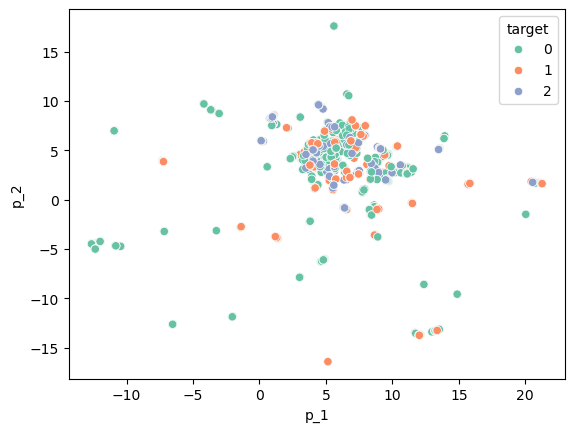

In [32]:
df_values = df_embedding.drop(columns=["target", "experimental_characteristics"])
nonlinear_instance = NonLinearReductions(dataset=df_values)

transform_values_umap = nonlinear_instance.applyUMAP()
transform_values_umap["target"] = df_embedding["target"].values

sns.scatterplot(data=transform_values_umap, x="p_1", y="p_2", hue="target", palette="Set2")


### ESM evaluation

In [42]:
name="esm1b_t33_650M_UR50S"

In [43]:
esm_based = ESMBasedEmbedding(
    name_device="cpu",
    dataset=df_data,
    name_model=f"facebook/{name}",
    name_tokenizer=f"facebook/{name}",
    column_seq="sequence",
    columns_ignore=["target", "experimental_characteristics"],
)

print("Loading model/tokenizer")
esm_based.load_model_tokenizer()

print("Generating embedding")
df_embedding = esm_based.embedding_process(batch_size=5)
if name_data == "antiviral_homology_90_Q":
    df_embedding.to_csv(f"../../data/numerical_rep_reg/embedding_{name_data}_{name}.csv", index=False)
else:
    df_embedding.to_csv(f"../../data/numerical_rep/embedding_{name_data}_{name}.csv", index=False)
esm_based.cleaning_memory()
print("Process finished")

df_embedding

Using device:  cpu
Loading model/tokenizer


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm1b_t33_650M_UR50S and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Generating embedding


[+] Embedding: 100%|██████████| 263/263 [01:35<00:00,  2.74batch/s]


Empty cache memory
Process finished


,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_9,p_10,...,p_1273,p_1274,p_1275,p_1276,p_1277,p_1278,p_1279,p_1280,target,experimental_characteristics
0,-0.189329,-0.106120,0.121437,-0.170978,-0.413113,-0.002667,-0.118141,0.258202,0.036604,0.006160,...,-0.220238,0.345471,-0.325690,0.002675,0.049569,-0.065406,0.006225,-0.132389,1,Mammalian
1,0.054793,-0.032901,-0.059837,0.140444,-0.087999,-0.142503,-0.046726,-0.012974,0.100228,0.081053,...,0.013086,0.106369,-0.359361,0.129411,-0.094747,-0.077288,0.117290,-0.007749,1,Mammalian
2,-0.150664,-0.225856,0.244287,0.141432,-0.400048,-0.089274,0.048838,0.200980,0.101737,-0.093454,...,0.138976,0.184034,0.672084,0.086928,-0.238005,-0.178675,0.091199,-0.257527,1,Mammalian
3,0.136161,0.020831,0.140237,0.167214,-0.112174,-0.045372,-0.053829,-0.074477,-0.138098,-0.048089,...,0.026764,0.048689,-0.989398,-0.055468,0.132881,-0.006171,0.116732,0.174790,1,Mammalian
4,0.049339,0.088812,-0.161759,0.202061,0.291150,0.325439,0.099139,0.052893,0.082604,-0.500550,...,-0.044096,0.021934,-2.356663,0.064255,-0.733392,-0.147906,-0.067209,-0.382670,1,Mammalian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1308,0.044638,0.014738,0.054417,0.165305,-0.149771,-0.145794,-0.054317,0.009583,0.110359,0.033287,...,0.041704,0.108708,-0.175154,0.096798,0.006256,-0.073547,0.132604,-0.031654,1,Mammalian
1309,0.084286,-0.162015,0.061148,0.145413,-0.030450,-0.112624,-0.170038,0.005528,0.130511,-0.018274,...,0.028209,0.184781,-0.073734,0.112651,0.002204,-0.058072,0.253552,-0.116554,0,E_coli
1310,0.130494,0.008716,0.064436,0.134387,-0.001227,-0.044284,-0.136776,-0.004319,-0.069247,-0.035375,...,-0.066484,0.130865,-0.826852,-0.016485,0.207187,-0.126368,0.188438,-0.106504,1,Mammalian
1311,0.130494,0.008716,0.064436,0.134387,-0.001227,-0.044284,-0.136776,-0.004318,-0.069247,-0.035374,...,-0.066484,0.130865,-0.826852,-0.016485,0.207187,-0.126368,0.188438,-0.106504,2,Yeast


<Axes: xlabel='p_1', ylabel='p_2'>

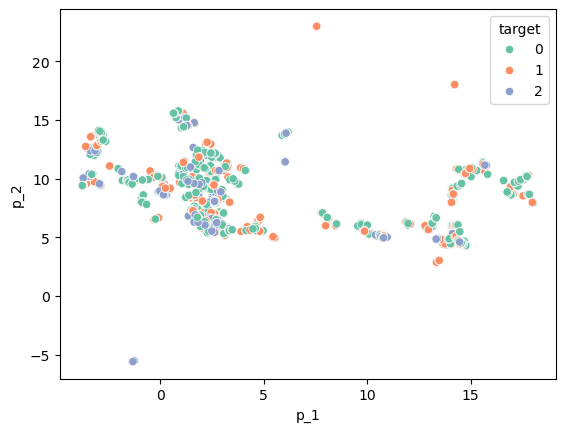

In [35]:
df_values = df_embedding.drop(columns=["target", "experimental_characteristics"])
nonlinear_instance = NonLinearReductions(dataset=df_values)

transform_values_umap = nonlinear_instance.applyUMAP()
transform_values_umap["target"] = df_embedding["target"].values

sns.scatterplot(data=transform_values_umap, x="p_1", y="p_2", hue="target", palette="Set2")


### Bert evaluation

In [36]:
df_to_bert = df_data.copy()
df_to_bert["sequence"] = df_to_bert["sequence"].apply(lambda x: " ".join(x)) # this process is necessary for the application of the pre-trained model

bert_based = BertBasedMebedding(
    name_device="cuda",
    dataset=df_to_bert,
    name_model="Rostlab/prot_bert_bfd_ss3",
    name_tokenizer="Rostlab/prot_bert_bfd_ss3",
    column_seq="sequence",
    columns_ignore=["target", "experimental_characteristics"],
)

print("Loading model/tokenizer")
bert_based.load_model_tokenizer()

print("Generating embedding")
df_embedding = bert_based.embedding_process(batch_size=5)

bert_based.cleaning_memory()
print("Process finished")

df_embedding

Using device:  cuda
Loading model/tokenizer


Some weights of BertModel were not initialized from the model checkpoint at Rostlab/prot_bert_bfd_ss3 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Generating embedding


[+] Embedding: 100%|██████████| 263/263 [00:04<00:00, 53.27batch/s]

Empty cache memory
Process finished


,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_9,p_10,...,p_1017,p_1018,p_1019,p_1020,p_1021,p_1022,p_1023,p_1024,target,experimental_characteristics
0,0.260225,-0.217249,0.088869,-0.074754,0.574013,0.044562,-0.122520,0.055145,0.082556,0.129106,...,0.027294,0.074977,0.122114,-0.183836,-0.354488,-0.002164,0.006765,0.028590,1,Mammalian
1,0.314682,-0.179533,-0.006838,0.003932,0.420641,0.124837,-0.217632,0.023801,0.067326,0.167940,...,-0.001602,-0.002870,0.072500,-0.107282,-0.430164,-0.022205,-0.053454,0.059421,1,Mammalian
2,0.186822,-0.278917,0.102844,-0.033482,0.433692,-0.004940,-0.162343,-0.078719,0.021046,0.061938,...,-0.072433,0.142439,-0.084590,-0.156430,-0.252827,0.085939,-0.023456,0.026674,1,Mammalian
3,0.288004,-0.148268,0.007012,0.020270,0.408574,0.106383,-0.164068,-0.019932,0.059656,0.164237,...,-0.023913,0.036407,-0.005943,-0.020471,-0.407084,-0.054650,-0.079631,0.054065,1,Mammalian
4,0.335294,-0.111949,0.080939,-0.041269,0.482987,0.055407,-0.114266,0.093932,0.139330,0.240620,...,0.055036,0.007440,0.131935,-0.067353,-0.428910,-0.076511,0.006969,0.073517,1,Mammalian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1308,0.219877,-0.232945,0.021378,-0.015632,0.459086,0.057039,-0.186250,-0.044673,0.080317,0.168570,...,-0.042148,0.096063,0.034793,-0.130957,-0.371430,0.008031,-0.015792,0.022462,1,Mammalian
1309,0.254731,-0.184202,0.020211,-0.047647,0.451127,0.122015,-0.145036,-0.023360,0.082594,0.127864,...,-0.036382,0.062788,0.106721,-0.108989,-0.375357,-0.009968,-0.064261,0.046762,0,E_coli
1310,0.259640,-0.187849,0.016602,-0.047114,0.444144,0.124818,-0.150674,-0.020489,0.078548,0.131157,...,-0.034152,0.056844,0.107674,-0.111587,-0.378747,-0.014475,-0.063492,0.046648,1,Mammalian
1311,0.259640,-0.187849,0.016602,-0.047114,0.444144,0.124818,-0.150674,-0.020489,0.078548,0.131157,...,-0.034152,0.056844,0.107674,-0.111587,-0.378747,-0.014475,-0.063492,0.046648,2,Yeast


<Axes: xlabel='p_1', ylabel='p_2'>

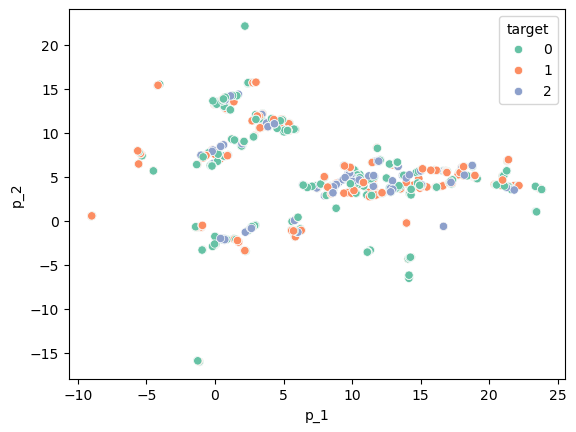

In [37]:
df_values = df_embedding.drop(columns=["target", "experimental_characteristics"])
nonlinear_instance = NonLinearReductions(dataset=df_values)

transform_values_umap = nonlinear_instance.applyUMAP()
transform_values_umap["target"] = df_embedding["target"].values

sns.scatterplot(data=transform_values_umap, x="p_1", y="p_2", hue="target", palette="Set2")
